In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()

early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)
baseline_model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8973 - loss: 0.3705 - val_accuracy: 0.9482 - val_loss: 0.1847
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9557 - loss: 0.1524 - val_accuracy: 0.9624 - val_loss: 0.1290
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9690 - loss: 0.1069 - val_accuracy: 0.9643 - val_loss: 0.1160
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9760 - loss: 0.0799 - val_accuracy: 0.9690 - val_loss: 0.1013
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9810 - loss: 0.0652 - val_accuracy: 0.9719 - val_loss: 0.0934
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9843 - loss: 0.0523 - val_accuracy: 0.9706 - val_loss: 0.1005
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9871 - loss: 0.0420 - val_accuracy: 0.9727 - val_loss: 0.0942
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9896 - loss: 0.0351 - val_accuracy: 0.

In [2]:
dropout_model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = dropout_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7304 - loss: 0.8378 - val_accuracy: 0.9247 - val_loss: 0.2585
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8857 - loss: 0.4063 - val_accuracy: 0.9467 - val_loss: 0.1897
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9067 - loss: 0.3283 - val_accuracy: 0.9529 - val_loss: 0.1727


In [3]:
l2_model = models.Sequential([
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 input_shape=(784,)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])

l2_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_l2 = l2_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8934 - loss: 0.5860 - val_accuracy: 0.9369 - val_loss: 0.3884
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9495 - loss: 0.3310 - val_accuracy: 0.9578 - val_loss: 0.2985
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9621 - loss: 0.2699 - val_accuracy: 0.9666 - val_loss: 0.2468


In [4]:
bn_model = models.Sequential([
    layers.Dense(128, input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')
])

bn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bn = bn_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9125 - loss: 0.3233 - val_accuracy: 0.9535 - val_loss: 0.1616
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9672 - loss: 0.1167 - val_accuracy: 0.9655 - val_loss: 0.1138
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9776 - loss: 0.0771 - val_accuracy: 0.9737 - val_loss: 0.0893
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9849 - loss: 0.0529 - val_accuracy: 0.9746 - val_loss: 0.0841
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9885 - loss: 0.0403 - val_accuracy: 0.9714 - val_loss: 0.0970
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9908 - loss: 0.0312 - val_accuracy: 0.9726 - val_loss: 0.0892
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9926 - loss: 0.0251 - val_accuracy: 0.9721 - val_loss: 0.0996


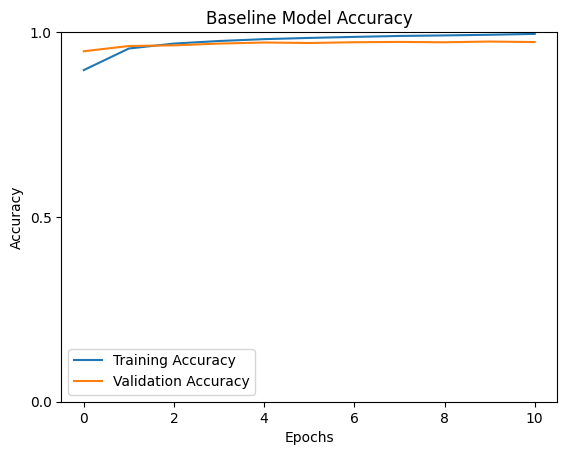

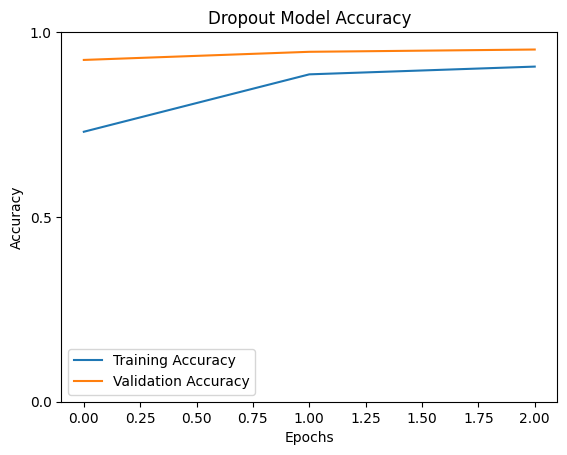

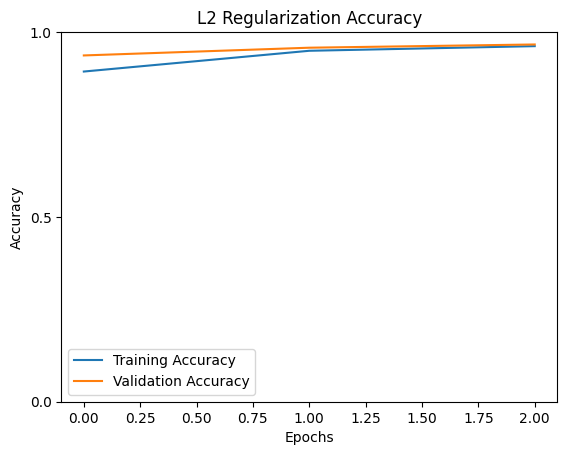

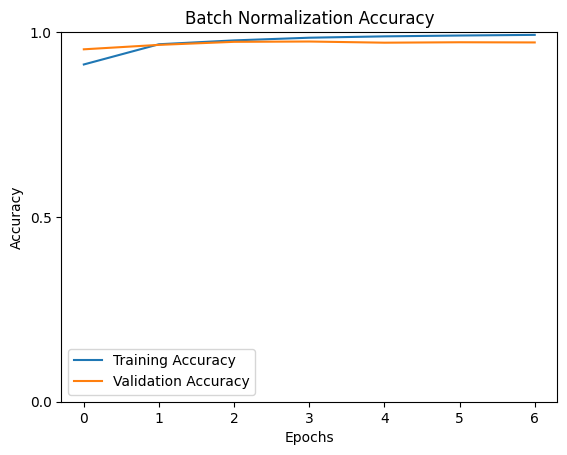

In [5]:
def plot_loss(history, title):
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    # Structured Y-axis
    plt.ylim(0, 1)
    plt.yticks([0.0,0.5,1.0])

    plt.legend()
    plt.show()

plot_loss(history_baseline, "Baseline Model Accuracy")
plot_loss(history_dropout, "Dropout Model Accuracy")
plot_loss(history_l2, "L2 Regularization Accuracy")
plot_loss(history_bn, "Batch Normalization Accuracy")


In [6]:
models_list = {
    "Baseline": baseline_model,
    "Dropout": dropout_model,
    "L2 Regularization": l2_model,
    "Batch Normalization": bn_model
}

for name, model in models_list.items():
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{name} Test Accuracy: {acc:.4f}")

Baseline Test Accuracy: 0.9749
Dropout Test Accuracy: 0.9224
L2 Regularization Test Accuracy: 0.9363
Batch Normalization Test Accuracy: 0.9759
